<a href="https://colab.research.google.com/github/Dilshan-Pasindu/Machine-Learning--Lab/blob/main/ML_Lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

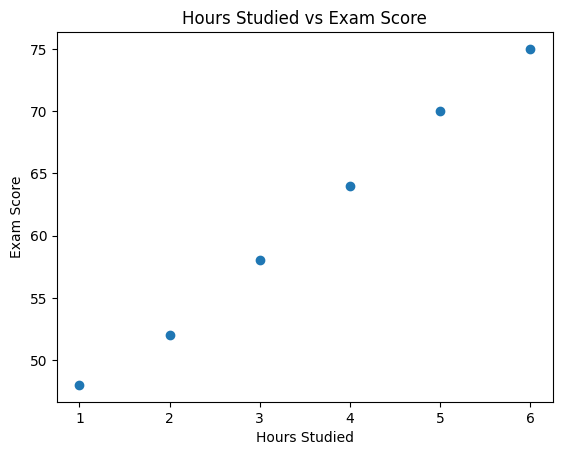

In [42]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5, 6])
y = np.array([48, 52, 58, 64, 70, 75])

plt.scatter(X, y)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()


In [43]:
beta0 = 0
beta1 = 0


In [44]:
def predict(X, beta0, beta1):
    return beta0 + beta1 * X


beta0 = 0
beta1 = 0

y_hat = predict(X, beta0, beta1)

print(y_hat)

[0 0 0 0 0 0]


In [45]:
# Calculate residuals
residuals = y - y_hat

print("Residuals:")
print(residuals)

Residuals:
[48 52 58 64 70 75]


In [46]:
def mse(y, y_hat):
    errors = y - y_hat
    squared_errors = errors ** 2
    return np.mean(squared_errors)

mse_value = mse(y, y_hat)

print("MSE:", mse_value)

MSE: 3832.1666666666665


In [47]:
print("Actual\tPredicted\tResidual")

for actual, predicted, residual in zip(y, y_hat, residuals):
    print(f"{actual}\t{predicted}\t\t{residual}")

Actual	Predicted	Residual
48	0		48
52	0		52
58	0		58
64	0		64
70	0		70
75	0		75


In [48]:
learning_rate = 0.01
iterations = 1000

beta0 = 0.0
beta1 = 0.0

loss_history = []

n = len(X)

for i in range(iterations):

    # Prediction
    y_hat = predict(X, beta0, beta1)

    # Gradients
    dbeta0 = (2 / n) * np.sum(y_hat - y)

    dbeta1 = (2 / n) * np.sum((y_hat - y) * X)

    # Update parameters
    beta0 = beta0 - learning_rate * dbeta0
    beta1 = beta1 - learning_rate * dbeta1

    # Calculate MSE
    current_mse = mse(y, predict(X, beta0, beta1))

    loss_history.append(current_mse)

print("Final beta0:", beta0)
print("Final beta1:", beta1)
print("Final MSE:", loss_history[-1])

Final beta0: 40.677869855813654
Final beta1: 5.802391188768685
Final MSE: 0.45798128772620866


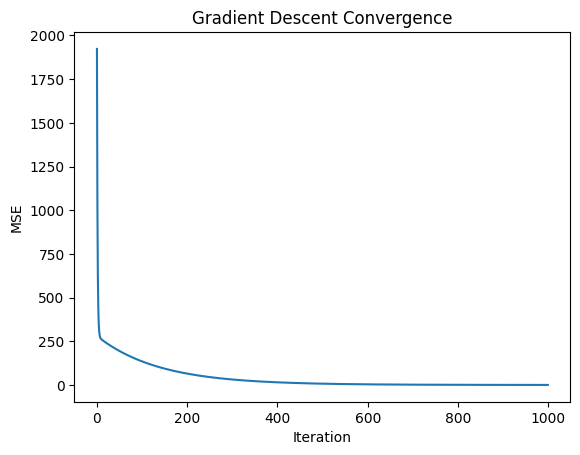

In [49]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence")
plt.show()

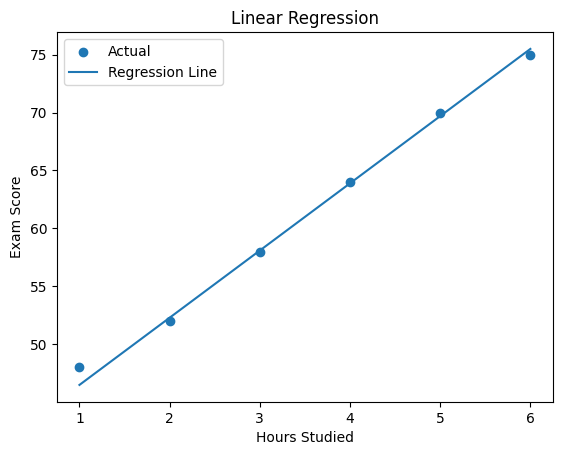

In [50]:
final_predictions = predict(X, beta0, beta1)

plt.scatter(X, y, label="Actual")

plt.plot(X, final_predictions, label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [51]:
def mae(y, y_hat):
    return np.mean(np.abs(y - y_hat))

In [52]:
def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

In [53]:
def rmse(y, y_hat):
    return np.sqrt(mse(y, y_hat))

In [54]:
def r2_score_manual(y, y_hat):

    ss_res = np.sum((y - y_hat) ** 2)

    ss_tot = np.sum((y - np.mean(y)) ** 2)

    return 1 - (ss_res / ss_tot)

In [55]:
beta0_ols = 41.6666666667
beta1_ols = 5.57142857143

pred_ols = predict(X, beta0_ols, beta1_ols)

print("MAE :", mae(y, pred_ols))
print("MSE :", mse(y, pred_ols))
print("RMSE:", rmse(y, pred_ols))
print("R²  :", r2_score_manual(y, pred_ols))

MAE : 0.42857142857166625
MSE : 0.2698412698412705
RMSE: 0.5194624816493204
R²  : 0.9970283616658655


In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X.reshape(-1, 1), y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

prediction = model.predict([[4.5]])

print("Prediction for 4.5 hours:", prediction[0])

Intercept: 41.666666666666664
Coefficient: 5.571428571428571
Prediction for 4.5 hours: 66.73809523809524


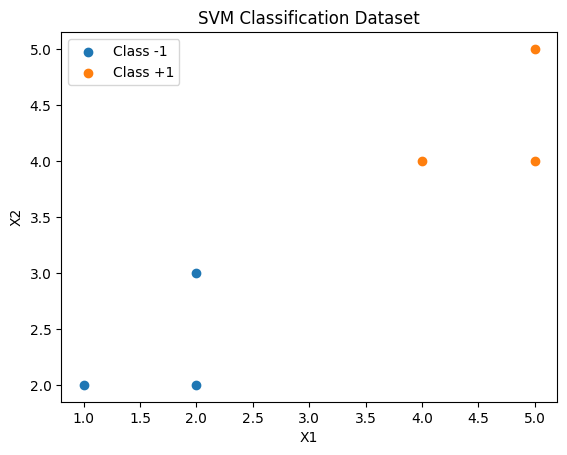

In [57]:
X = np.array([
    [1,2],
    [2,2],
    [2,3],
    [4,4],
    [5,4],
    [5,5]
])

y = np.array([-1,-1,-1,1,1,1])

plt.scatter(X[y == -1, 0], X[y == -1, 1], label="Class -1")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class +1")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Classification Dataset")
plt.legend()
plt.show()

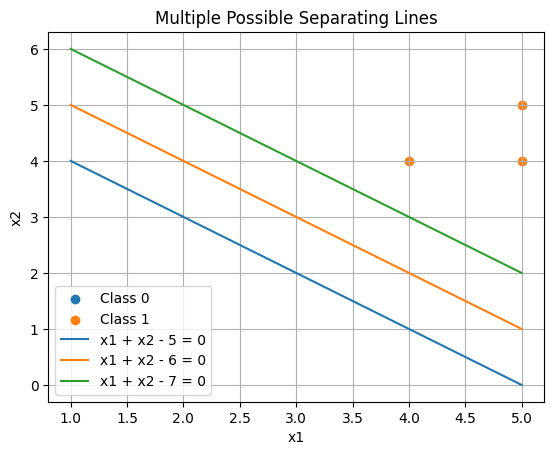

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")

# Values for x1
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

# Different separating lines
x2_1 = 5 - x1
x2_2 = 6 - x1
x2_3 = 7 - x1

plt.plot(x1, x2_1, label="x1 + x2 - 5 = 0")
plt.plot(x1, x2_2, label="x1 + x2 - 6 = 0")
plt.plot(x1, x2_3, label="x1 + x2 - 7 = 0")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Multiple Possible Separating Lines")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
from sklearn.svm import SVC

svc = SVC(
    kernel="linear",
    C=1.0
)

svc.fit(X, y)

w = svc.coef_[0]
b = svc.intercept_[0]

print("w =", w)
print("b =", b)

w = [0.8 0.4]
b = -3.8000000000000003


In [60]:
scores = X @ w + b

print(scores)

[-2.2 -1.4 -1.   1.   1.8  2.2]


In [61]:
print(svc.decision_function(X))
print(svc.predict(X))

[-2.2 -1.4 -1.   1.   1.8  2.2]
[-1 -1 -1  1  1  1]


In [62]:
scores = X @ w + b

svm_scores = svc.decision_function(X)

print("Hand-computed scores:")
print(scores)

print("\nSVC decision function:")
print(svm_scores)

Hand-computed scores:
[-2.2 -1.4 -1.   1.   1.8  2.2]

SVC decision function:
[-2.2 -1.4 -1.   1.   1.8  2.2]


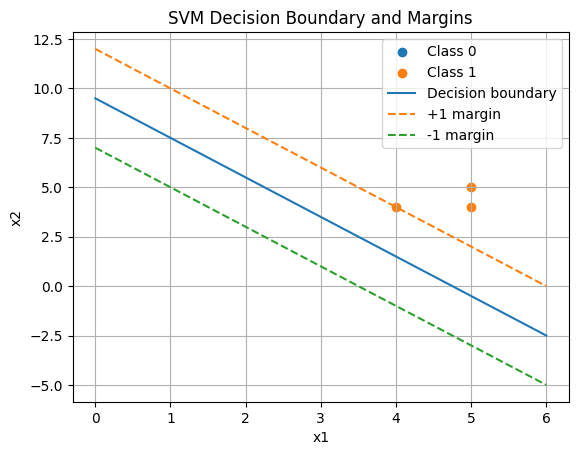

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Get weights and bias
w = svc.coef_[0]
b = svc.intercept_[0]

# Create x1 values
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)

# Calculate the three boundaries
x2_decision = -(w[0] * x1 + b) / w[1]
x2_margin_positive = -(w[0] * x1 + b - 1) / w[1]
x2_margin_negative = -(w[0] * x1 + b + 1) / w[1]

# Plot classes
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

# Plot decision boundary
plt.plot(
    x1,
    x2_decision,
    label="Decision boundary"
)

# Plot margin boundaries
plt.plot(
    x1,
    x2_margin_positive,
    linestyle="--",
    label="+1 margin"
)

plt.plot(
    x1,
    x2_margin_negative,
    linestyle="--",
    label="-1 margin"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVM Decision Boundary and Margins")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
print("Support vectors:")
print(svc.support_vectors_)

Support vectors:
[[2. 3.]
 [4. 4.]]


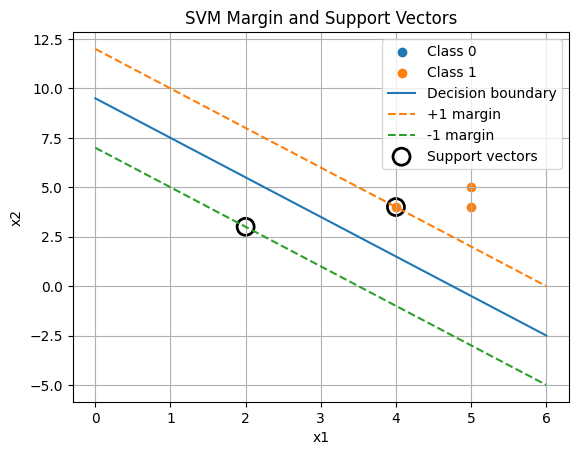

In [65]:
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

# Decision boundary
plt.plot(
    x1,
    x2_decision,
    label="Decision boundary"
)

# Margin boundaries
plt.plot(
    x1,
    x2_margin_positive,
    linestyle="--",
    label="+1 margin"
)

plt.plot(
    x1,
    x2_margin_negative,
    linestyle="--",
    label="-1 margin"
)

# Support vectors
plt.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support vectors"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVM Margin and Support Vectors")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
scores = svc.decision_function(X)

In [67]:
hinge = np.maximum(0, 1 - y * scores)

In [68]:
scores = svc.decision_function(X)
hinge = np.maximum(0, 1 - y * scores)

print("Support vector indices:")
print(svc.support_)

print("\nZero hinge-loss indices:")
print(np.where(hinge <= 1e-10)[0])

Support vector indices:
[2 3]

Zero hinge-loss indices:
[0 1 2 3 4 5]


In [69]:
from sklearn.svm import SVR

SVR(
    kernel='linear',
    C=1.0,
    epsilon=1.0
)

SVR(epsilon=1.0, kernel='linear')

In [70]:
from sklearn.svm import SVR
import numpy as np

# Redefine X and y for the regression task
X = np.array([1, 2, 3, 4, 5, 6])
y = np.array([48, 52, 58, 64, 70, 75])

svr = SVR(
    kernel='linear',
    C=1.0,
    epsilon=1.0
)

# Reshape X to be a 2D array for the fit method
svr.fit(X.reshape(-1, 1), y)

w = svr.coef_[0][0]
b = svr.intercept_[0]

print("w =", w)
print("b =", b)

preds_hand = w * X.ravel() + b

print(preds_hand)

w = 5.0
b = 44.0
[49. 54. 59. 64. 69. 74.]


In [71]:
preds_sklearn = svr.predict(X.reshape(-1, 1))

print(preds_sklearn)

[49. 54. 59. 64. 69. 74.]


In [72]:
for actual, predicted in zip(y, preds_hand):
    print(f"Actual: {actual:.2f}, Predicted: {predicted:.2f}")

Actual: 48.00, Predicted: 49.00
Actual: 52.00, Predicted: 54.00
Actual: 58.00, Predicted: 59.00
Actual: 64.00, Predicted: 64.00
Actual: 70.00, Predicted: 69.00
Actual: 75.00, Predicted: 74.00


In [73]:
import pandas as pd

results = pd.DataFrame({
    "Actual Score": y,
    "Predicted Score": preds_hand
})

print(results)

   Actual Score  Predicted Score
0            48             49.0
1            52             54.0
2            58             59.0
3            64             64.0
4            70             69.0
5            75             74.0


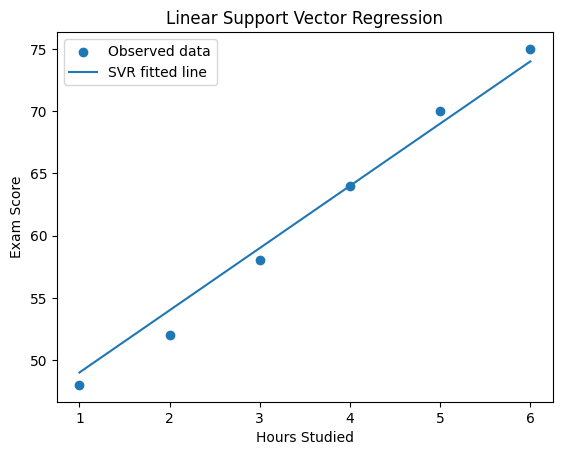

In [74]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Observed data")

plt.plot(
    X.ravel(),
    preds_hand,
    label="SVR fitted line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Support Vector Regression")
plt.legend()
plt.show()

Upper boundary:
[50. 55. 60. 65. 70. 75.]

Lower boundary:
[48. 53. 58. 63. 68. 73.]

Support vector indices:
[1 2 4 5]


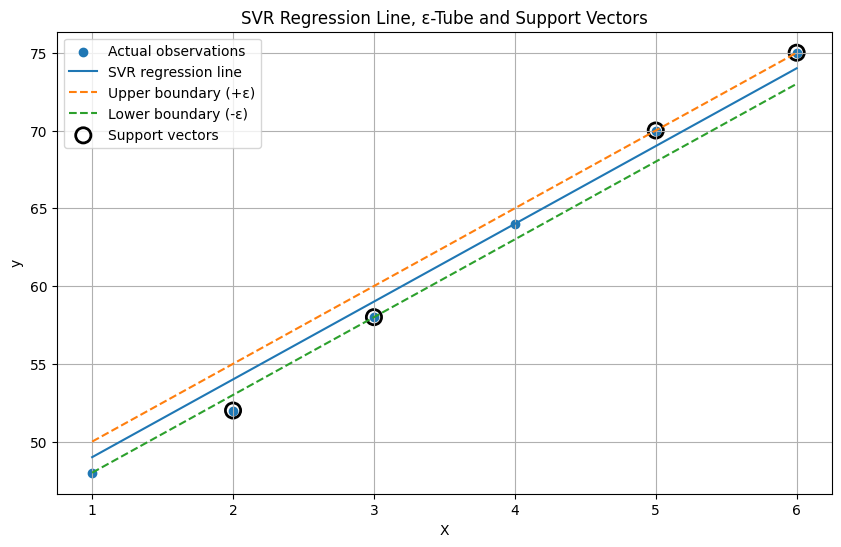


Observations strictly inside the epsilon-tube:
[3]

Observations on or outside the epsilon-tube:
[0 1 2 4 5]

--- Detailed observation information ---
Index 0: Actual = 48.0000, Predicted = 49.0000, Residual = -1.0000, Position = On or outside
Index 1: Actual = 52.0000, Predicted = 54.0000, Residual = -2.0000, Position = On or outside
Index 2: Actual = 58.0000, Predicted = 59.0000, Residual = -1.0000, Position = On or outside
Index 3: Actual = 64.0000, Predicted = 64.0000, Residual = 0.0000, Position = Inside
Index 4: Actual = 70.0000, Predicted = 69.0000, Residual = 1.0000, Position = On or outside
Index 5: Actual = 75.0000, Predicted = 74.0000, Residual = 1.0000, Position = On or outside


In [75]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Task 12 - Visualize the epsilon-tube
# --------------------------------------------------

# Epsilon
epsilon = 1.0

# Predictions
y_pred = svr.predict(X.reshape(-1, 1))

# 1. Calculate epsilon-tube boundaries
upper = y_pred + epsilon
lower = y_pred - epsilon

# Identify observations
inside = np.abs(y - y_pred) < epsilon
outside_or_boundary = ~inside

# --------------------------------------------------
# Print boundaries
# --------------------------------------------------

print("Upper boundary:")
print(upper)

print("\nLower boundary:")
print(lower)

# --------------------------------------------------
# 2. Sort values for smooth plotting
# --------------------------------------------------

sort_idx = np.argsort(X.ravel())

X_sorted = X.ravel()[sort_idx]
y_pred_sorted = y_pred[sort_idx]
upper_sorted = upper[sort_idx]
lower_sorted = lower[sort_idx]

# --------------------------------------------------
# 3. Support vectors
# --------------------------------------------------

support_indices = svr.support_

print("\nSupport vector indices:")
print(support_indices)

X_support = X[support_indices]
y_support = y[support_indices]

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

# Actual observations
plt.scatter(
    X,
    y,
    label="Actual observations"
)

# Regression line
plt.plot(
    X_sorted,
    y_pred_sorted,
    label="SVR regression line"
)

# Upper epsilon boundary
plt.plot(
    X_sorted,
    upper_sorted,
    linestyle="--",
    label="Upper boundary (+ε)"
)

# Lower epsilon boundary
plt.plot(
    X_sorted,
    lower_sorted,
    linestyle="--",
    label="Lower boundary (-ε)"
)

# Support vectors
plt.scatter(
    X_support,
    y_support,
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support vectors"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("SVR Regression Line, ε-Tube and Support Vectors")
plt.legend()
plt.grid(True)

plt.show()

# --------------------------------------------------
# 4. Inside / boundary / outside observations
# --------------------------------------------------

inside_indices = np.where(inside)[0]
boundary_indices = np.where(~inside)[0]

print("\nObservations strictly inside the epsilon-tube:")
print(inside_indices)

print("\nObservations on or outside the epsilon-tube:")
print(boundary_indices)

# Detailed information
print("\n--- Detailed observation information ---")

for i in range(len(y)):
    residual = y[i] - y_pred[i]

    if abs(residual) < epsilon:
        position = "Inside"
    else:
        position = "On or outside"

    print(
        f"Index {i}: "
        f"Actual = {y[i]:.4f}, "
        f"Predicted = {y_pred[i]:.4f}, "
        f"Residual = {residual:.4f}, "
        f"Position = {position}"
    )

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Epsilon value
epsilon = 1.0

# Predictions from the trained SVR model
y_pred = svr.predict(X.reshape(-1, 1))

# Calculate epsilon-tube boundaries
upper = y_pred + epsilon
lower = y_pred - epsilon

# Identify observations strictly inside the tube
inside = np.abs(y - y_pred) < epsilon

# Identify observations on or outside the tube
outside_or_boundary = ~inside

print("Predicted values:")
print(y_pred)

print("\nUpper boundary:")
print(upper)

print("\nLower boundary:")
print(lower)

print("\nInside the epsilon-tube:")
print(inside)

print("\nOn or outside the epsilon-tube:")
print(outside_or_boundary)

Predicted values:
[49. 54. 59. 64. 69. 74.]

Upper boundary:
[50. 55. 60. 65. 70. 75.]

Lower boundary:
[48. 53. 58. 63. 68. 73.]

Inside the epsilon-tube:
[False False False  True False False]

On or outside the epsilon-tube:
[ True  True  True False  True  True]


In [77]:
preds = svr.predict(X.reshape(-1, 1))

loss = np.maximum(
    0,
    np.abs(y - preds) - svr.epsilon
)

print("ε-insensitive loss:")
print(loss)

ε-insensitive loss:
[0. 1. 0. 0. 0. 0.]


In [78]:
import pandas as pd
import numpy as np

# Predictions
preds = svr.predict(X.reshape(-1, 1))

# Absolute error
absolute_error = np.abs(y - preds)

# Epsilon-insensitive loss
loss = np.maximum(
    0,
    absolute_error - svr.epsilon
)

# Create table
results = pd.DataFrame({
    "Actual": y,
    "Predicted": preds,
    "Absolute Error": absolute_error,
    "Loss": loss
})

print(results)

   Actual  Predicted  Absolute Error  Loss
0      48       49.0             1.0   0.0
1      52       54.0             2.0   1.0
2      58       59.0             1.0   0.0
3      64       64.0             0.0   0.0
4      70       69.0             1.0   0.0
5      75       74.0             1.0   0.0


In [79]:
from sklearn.svm import SVR
import numpy as np

# Redefine X and y for the regression task to ensure context
X = np.array([1, 2, 3, 4, 5, 6])
y = np.array([48, 52, 58, 64, 70, 75])

# Instantiate and fit SVR model
svr = SVR(
    kernel='linear',
    C=1.0,
    epsilon=1.0
)
svr.fit(X.reshape(-1, 1), y)

# Calculate predictions
preds = svr.predict(X.reshape(-1, 1))

# Calculate epsilon-insensitive loss
loss = np.maximum(
    0,
    np.abs(y - preds) - svr.epsilon
)

# Find observations with zero loss
zero_loss_indices = np.where(loss == 0)[0]

# Get support vector indices
support_indices = svr.support_

# Print results
print("Zero-loss observation indices:")
print(zero_loss_indices)

print("\nSupport vector indices:")
print(support_indices)

# Compare the two sets
common_indices = np.intersect1d(
    zero_loss_indices,
    support_indices
)

print("\nZero-loss observations that are also support vectors:")
print(common_indices)

# Display detailed comparison
print("\n--- Detailed Comparison ---")

for i in range(len(y)):
    is_zero_loss = loss[i] == 0
    is_support = i in support_indices

    print(
        f"Index {i}: "
        f"Actual = {y[i]:.4f}, "
        f"Predicted = {preds[i]:.4f}, "
        f"Absolute Error = {abs(y[i] - preds[i]):.4f}, "
        f"Loss = {loss[i]:.4f}, "
        f"Zero Loss = {is_zero_loss}, "
        f"Support Vector = {is_support}"
    )

Zero-loss observation indices:
[0 2 3 4 5]

Support vector indices:
[1 2 4 5]

Zero-loss observations that are also support vectors:
[2 4 5]

--- Detailed Comparison ---
Index 0: Actual = 48.0000, Predicted = 49.0000, Absolute Error = 1.0000, Loss = 0.0000, Zero Loss = True, Support Vector = False
Index 1: Actual = 52.0000, Predicted = 54.0000, Absolute Error = 2.0000, Loss = 1.0000, Zero Loss = False, Support Vector = True
Index 2: Actual = 58.0000, Predicted = 59.0000, Absolute Error = 1.0000, Loss = 0.0000, Zero Loss = True, Support Vector = True
Index 3: Actual = 64.0000, Predicted = 64.0000, Absolute Error = 0.0000, Loss = 0.0000, Zero Loss = True, Support Vector = False
Index 4: Actual = 70.0000, Predicted = 69.0000, Absolute Error = 1.0000, Loss = 0.0000, Zero Loss = True, Support Vector = True
Index 5: Actual = 75.0000, Predicted = 74.0000, Absolute Error = 1.0000, Loss = 0.0000, Zero Loss = True, Support Vector = True
